<a href="https://colab.research.google.com/github/khushbukushwaha1182-ops/Packaged-foods-In-India/blob/main/Packaged_foods_India_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving packaged_foods_india.csv to packaged_foods_india.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('packaged_foods_india.csv')

In [4]:
df.head()

,S.No,Item name,Brand_Name,Category,Sub_Category,Ingredients,Serving_Size_g,Calories_kcal,Carbohydrates_g,Proteins_g,...,Dietary_Fiber_g,Cholesterol_mg,Calcium_mg,Vitamin,Iron_mg,Price_INR,Source_of_Data,Collection_Date,Collected_By,Remarks
0,1,HIDE & SEEK®,PARLE,BISCUIT,COOKIES,"REFINED WHEAT FLOUR (MAIDA), CHOCOLATE (23%) ...",100.0,479.0,73.4,5.9,...,0,0,0.0,0,0.0,30.0,ZEPTO,23-10-2025,NaN,NaN
1,2,Britannia Nutrichoice Digestive High-Fibre Bis...,BRITANNIA,BISCUIT,DIGESTIVE BISCUIT,"WHEAT FLOUR (ATTA) (65.5%), REFINED PALM OIL, ...",100.0,483.0,68.0,9.3,...,6.7,0.1,0.0,0,0.0,20.0,NaN,NaN,NaN,NaN
2,3,"Sunfeast Dark Fantasy Choco Fills, Original Fi...",SUNFEAST,BISCUIT,CHOCO FILLS,"SUGAR, REFINED PALMOLEIN, REFINED PALM OIL, C...",100.0,507.0,61.1,7.3,...,0,0.3,0.0,0,0.0,170.0,NaN,NaN,NaN,NaN
3,4,Sunfeast Baked Creations Rich Choco Chip Cookies,SUNFEAST,BISCUIT,COOKIES,"MAIDA (REFINED WHEAT FLOUR), DARK CHOCOLATE CH...",20.0,105.0,12.6,1.2,...,0,1,0.0,0,0.0,25.0,NaN,NaN,NaN,NaN
4,5,"sunfeast Dark Fantasy Bourbon, Classic Biscuit...",SUNFEAST,BISCUIT,CREAME,"Cocoa Solids (2.3%), Emulsifiers lecithin (fro...",108.0,445.0,77.4,9.1,...,0,0.1,0.0,"Vitamin B1 (mg) 0.3, Vitamin B2 (mg0 0.3, Vita...",2.9,35.0,NaN,NaN,NaN,NaN


In [5]:
df.shape

(852, 25)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 852 entries, 0 to 851
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   S.No             852 non-null    int64  
 1   Item name        852 non-null    object 
 2   Brand_Name       852 non-null    object 
 3   Category         852 non-null    object 
 4   Sub_Category     852 non-null    object 
 5   Ingredients      852 non-null    object 
 6   Serving_Size_g   852 non-null    float64
 7   Calories_kcal    851 non-null    float64
 8   Carbohydrates_g  851 non-null    float64
 9   Proteins_g       851 non-null    object 
 10  Total_Fat_g      851 non-null    object 
 11  Saturated_Fat_g  849 non-null    object 
 12  Trans_Fat_g      849 non-null    object 
 13  Sugar_g          847 non-null    object 
 14  Sodium_mg        847 non-null    object 
 15  Dietary_Fiber_g  848 non-null    object 
 16  Cholesterol_mg   839 non-null    object 
 17  Calcium_mg      

In [7]:
df.columns

Index(['S.No', 'Item name', 'Brand_Name', 'Category', 'Sub_Category',
       'Ingredients', 'Serving_Size_g', 'Calories_kcal', 'Carbohydrates_g',
       'Proteins_g', 'Total_Fat_g', 'Saturated_Fat_g', 'Trans_Fat_g',
       'Sugar_g', 'Sodium_mg', 'Dietary_Fiber_g', 'Cholesterol_mg',
       'Calcium_mg', 'Vitamin', 'Iron_mg', 'Price_INR', 'Source_of_Data',
       'Collection_Date', 'Collected_By', 'Remarks'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
S.No,0
Item name,0
Brand_Name,0
Category,0
Sub_Category,0
Ingredients,0
Serving_Size_g,0
Calories_kcal,1
Carbohydrates_g,1
Proteins_g,1


In [9]:
#Now I would remove the 4 columns which are essentially empty, so they don't provide any analytical value.
df = df.drop(columns=[
    'Remarks',
    'Collected_By',
    'Collection_Date',
    'Source_of_Data'
])
print(df.shape)

(852, 21)


In [10]:
#Now I would handle the remaining missing values, before that I should convert several nutritional columns to numeric because they stored in object.
numeric_cols = [
    'Serving_Size_g',
    'Calories_kcal',
    'Carbohydrates_g',
    'Proteins_g',
    'Total_Fat_g',
    'Saturated_Fat_g',
    'Trans_Fat_g',
    'Cholesterol_mg',
    'Sodium_mg',
    'Sugar_g',
    'Dietary_Fiber_g',
    'Calcium_mg',
    'Iron_mg',
    'Price_INR'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [11]:
#Filling the numerical missing values with the median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())


In [12]:
#For Vitamin:
df['Vitamin'] = df['Vitamin'].fillna('Unknown')

In [13]:
#Checking the missing values again:
df.isnull().sum().sort_values(ascending=False)

,0
S.No,0
Item name,0
Brand_Name,0
Category,0
Sub_Category,0
Ingredients,0
Serving_Size_g,0
Calories_kcal,0
Carbohydrates_g,0
Proteins_g,0


In [14]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [15]:
#Check for duplicate rows
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [16]:
#Check for invalid numerical values
#Now we need to make sure things like price, calories, sugar, fat, protein etc aren't negative.
for col in numeric_cols:
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
       print(col, ":", negative_count, "negative values")


In [17]:
# Checking basic statistics
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Serving_Size_g,852.0,96.601373,27.031715,2.0,100.0000,100.000,100.0000,585.77
Calories_kcal,852.0,344.689038,186.954059,0.0,169.7500,390.000,494.6000,1634.00
Carbohydrates_g,852.0,47.665141,32.446741,0.0,18.2250,53.400,67.3250,532.80
Proteins_g,852.0,5.667465,5.404732,0.0,1.3000,5.600,7.8000,68.00
Total_Fat_g,852.0,15.062876,13.467953,0.0,2.2750,13.000,24.6500,80.00
Saturated_Fat_g,852.0,6.650469,7.031319,0.0,0.2000,4.650,10.8475,48.00
Trans_Fat_g,852.0,0.102621,1.515348,0.0,0.0000,0.000,0.0400,43.50
Cholesterol_mg,852.0,5.060880,18.746436,0.0,0.0000,0.000,0.9000,226.72
Sodium_mg,852.0,298.863662,642.569509,0.0,12.0000,113.700,382.9300,9107.60
Sugar_g,852.0,21.959918,22.593946,0.0,3.6525,14.225,33.0000,98.00


In [18]:
#Detect outliers using the IQR method
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = len(outliers)

outlier_summary

{'Serving_Size_g': 72,
 'Calories_kcal': 1,
 'Carbohydrates_g': 2,
 'Proteins_g': 24,
 'Total_Fat_g': 4,
 'Saturated_Fat_g': 9,
 'Trans_Fat_g': 92,
 'Cholesterol_mg': 180,
 'Sodium_mg': 52,
 'Sugar_g': 31,
 'Dietary_Fiber_g': 182,
 'Calcium_mg': 102,
 'Iron_mg': 58,
 'Price_INR': 44}

In [19]:
#Display outlier counts in a clean format
for col, count in outlier_summary.items():
    print(f"{col}: {count} outliers")

Serving_Size_g: 72 outliers
Calories_kcal: 1 outliers
Carbohydrates_g: 2 outliers
Proteins_g: 24 outliers
Total_Fat_g: 4 outliers
Saturated_Fat_g: 9 outliers
Trans_Fat_g: 92 outliers
Cholesterol_mg: 180 outliers
Sodium_mg: 52 outliers
Sugar_g: 31 outliers
Dietary_Fiber_g: 182 outliers
Calcium_mg: 102 outliers
Iron_mg: 58 outliers
Price_INR: 44 outliers


In [20]:
#Inspecting the actual outlier value that have a large number of outliers
def show_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"Outliers in {col}:")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Number of outliers: {len(outliers)}")
    print(outliers)
    return outliers


In [21]:
fiber_outliers = show_outliers(df, 'Dietary_Fiber_g')
fiber_outliers[
    ['Item name', 'Brand_Name', 'Dietary_Fiber_g', 'Price_INR']
].sort_values('Dietary_Fiber_g', ascending=False).head(20)

Outliers in Dietary_Fiber_g:
Lower bound: -1.05
Upper bound: 1.75
Number of outliers: 182
     S.No                                          Item name  \
1       2  Britannia Nutrichoice Digestive High-Fibre Bis...   
6       7  The Baker's Dozen Zero Maida Coconut and Oats ...   
8       9                              Nutrisum Oats Cookies   
11     12                      UNIBIC Danish Coconut Cookies   
13     14  Britannia Nutrichoice Oats Cookies Diabetic Fr...   
..    ...                                                ...   
831   832                       NIC Chocochips Ice Cream Tub   
838   839  Go Zero Mango Duet Low Calorie Guilt Free Ice ...   
840   841  Go Zero Hazelnut Chocolate Low Calorie Guilt F...   
845   846  Go Zero Raspberry Duet Low Calorie Guilt Free ...   
849   850          Grameen Kesar Pista Kulfi Ice Cream Stick   

            Brand_Name   Category       Sub_Category  \
1            BRITANNIA    BISCUIT  DIGESTIVE BISCUIT   
6    THE BAKER'S DOZEN    BIS

,Item name,Brand_Name,Dietary_Fiber_g,Price_INR
747,Wingreens Farms Tandoori Mayo,WINGREENS,653.70,75.0
792,Prasuma Frozen Chicken Seekh Kabab,PRASUMA,138.78,375.0
560,Doritos Dinamita Fiery Lime & Chilli Flavour N...,DORITOS,30.00,100.0
27,Orion Mango Choco Pie,ORION,18.60,90.0
676,Cookd Tandoori Tikka Kit,COOKD,17.00,149.0
213,Amul Gold Kool Royal Elaichi Flavoured Milk,AMUL,16.00,30.0
570,bb Gooddiet Crackers - Rock Salt & Pepper,BB GOODDIET,16.00,195.0
8,Nutrisum Oats Cookies,NUTRISUM,12.00,95.0
331,Too Yumm! Moong Dal | No Palm Oil | 35% Less S...,TOO YUMM,12.00,70.0
320,Farmley Cream And Onion Makhana Roasted In Oli...,FARMLEY,11.90,239.0


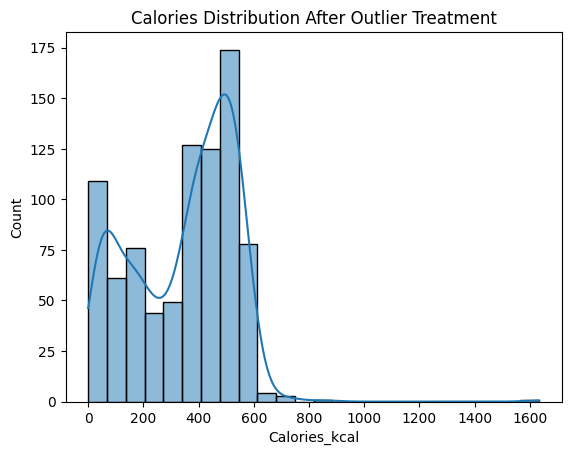

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['Calories_kcal'], kde=True)
plt.title('Calories Distribution After Outlier Treatment')
plt.show()

This graph is a histogram with the KDE curve, showing the distribution of Calories_kcal.
1. X- axis = This represents the range of calories values found in the food items.
2. Y- axis = This axis shows how many food items fall into each calorie range.

One group has very low calories(close to zero) and another large group has moderate calories(around 400-500 kcal). While most foods fall into those two groups, there are a few products with very high calorie counts.
So, the main takeaway is that the packaged foods in this dataset aren't sprrad evenly acorss all calorie levels, they tend to cluster around either very low or moderate calorie values, with only a few items being exceptionally high in calories.


In [23]:
#Checking the cleaned dataset
df.shape

(852, 21)

In [24]:
df.dtypes

,0
S.No,int64
Item name,object
Brand_Name,object
Category,object
Sub_Category,object
Ingredients,object
Serving_Size_g,float64
Calories_kcal,float64
Carbohydrates_g,float64
Proteins_g,float64


In [25]:
df.isnull().sum()

,0
S.No,0
Item name,0
Brand_Name,0
Category,0
Sub_Category,0
Ingredients,0
Serving_Size_g,0
Calories_kcal,0
Carbohydrates_g,0
Proteins_g,0


In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
S.No,852.0,426.500000,246.095510,1.0,213.7500,426.500,639.2500,852.00
Serving_Size_g,852.0,96.601373,27.031715,2.0,100.0000,100.000,100.0000,585.77
Calories_kcal,852.0,344.689038,186.954059,0.0,169.7500,390.000,494.6000,1634.00
Carbohydrates_g,852.0,47.665141,32.446741,0.0,18.2250,53.400,67.3250,532.80
Proteins_g,852.0,5.667465,5.404732,0.0,1.3000,5.600,7.8000,68.00
Total_Fat_g,852.0,15.062876,13.467953,0.0,2.2750,13.000,24.6500,80.00
Saturated_Fat_g,852.0,6.650469,7.031319,0.0,0.2000,4.650,10.8475,48.00
Trans_Fat_g,852.0,0.102621,1.515348,0.0,0.0000,0.000,0.0400,43.50
Sugar_g,852.0,21.959918,22.593946,0.0,3.6525,14.225,33.0000,98.00
Sodium_mg,852.0,298.863662,642.569509,0.0,12.0000,113.700,382.9300,9107.60


In [28]:
#Identify numerical columns
numeric_cols = df.select_dtypes(include=['number']).columns
print("Numerical Columns:")
print(numeric_cols)


Numerical Columns:
Index(['S.No', 'Serving_Size_g', 'Calories_kcal', 'Carbohydrates_g',
       'Proteins_g', 'Total_Fat_g', 'Saturated_Fat_g', 'Trans_Fat_g',
       'Sugar_g', 'Sodium_mg', 'Dietary_Fiber_g', 'Cholesterol_mg',
       'Calcium_mg', 'Iron_mg', 'Price_INR'],
      dtype='object')


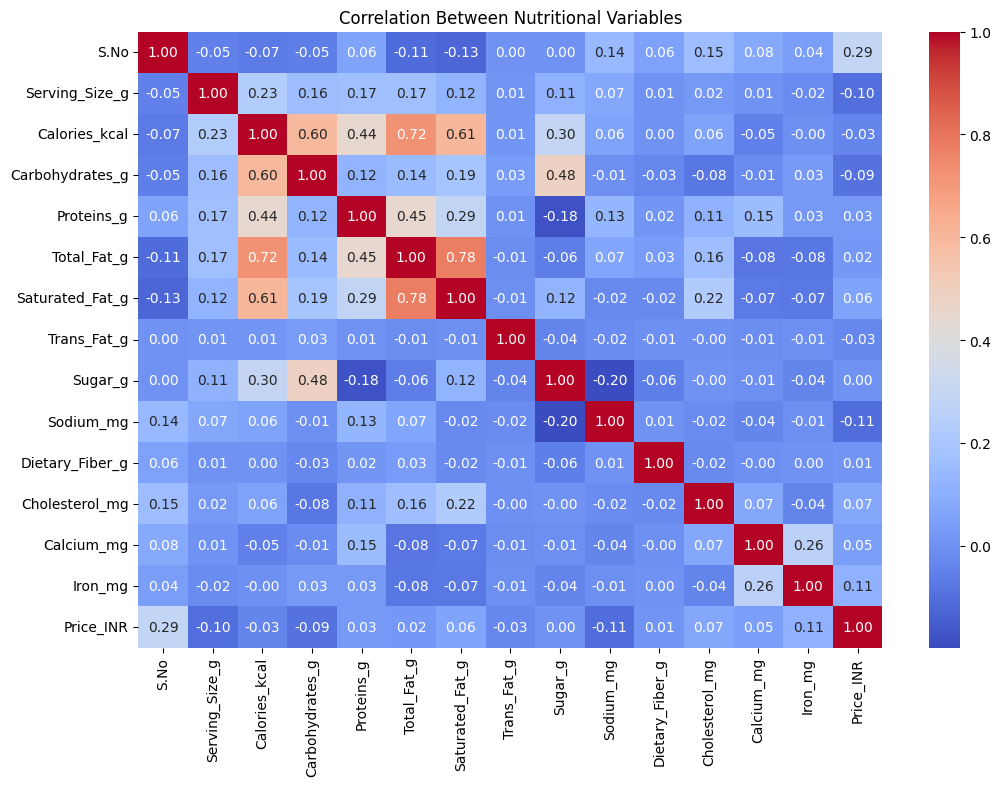

In [29]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Between Nutritional Variables")
plt.show()

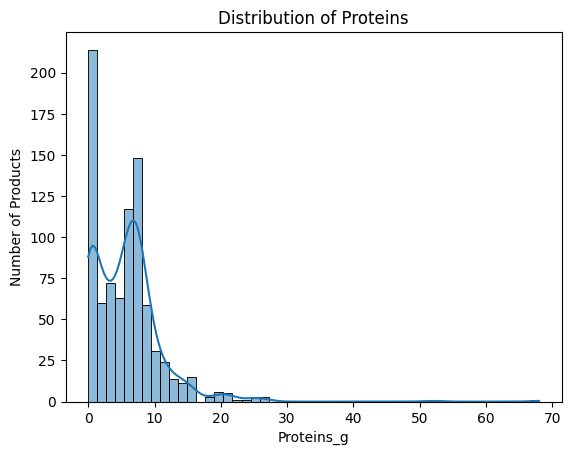

In [31]:
#Protein Distribution
sns.histplot(df['Proteins_g'], kde=True)
plt.title('Distribution of Proteins')
plt.xlabel('Proteins_g')
plt.ylabel('Number of Products')
plt.show()

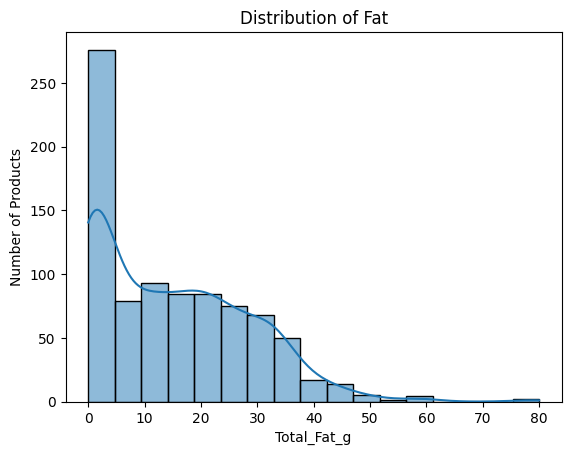

In [32]:
#Fat Distribution
sns.histplot(df['Total_Fat_g'], kde=True)
plt.title('Distribution of Fat')
plt.xlabel('Total_Fat_g')
plt.ylabel('Number of Products')
plt.show()


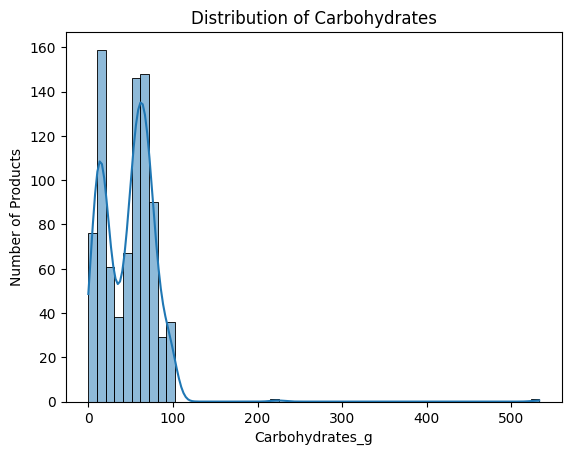

In [33]:
#Carbohydrates Distribution
sns.histplot(df['Carbohydrates_g'], kde=True)
plt.title('Distribution of Carbohydrates')
plt.xlabel('Carbohydrates_g')
plt.ylabel('Number of Products')
plt.show()


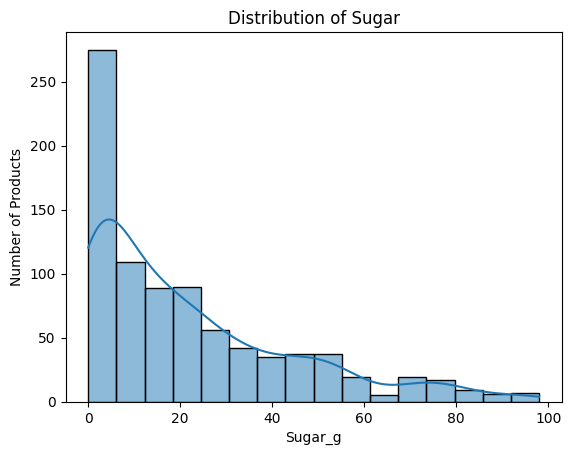

In [34]:
#Sugar Distribution
sns.histplot(df['Sugar_g'], kde=True)
plt.title('Distribution of Sugar')
plt.xlabel('Sugar_g')
plt.ylabel('Number of Products')
plt.show()

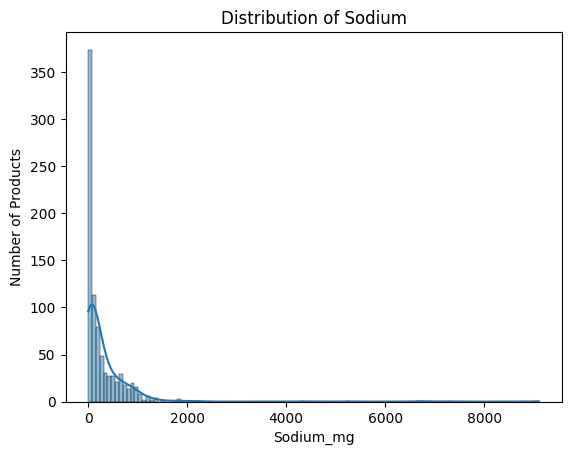

In [35]:
#Sodium Distribution
sns.histplot(df['Sodium_mg'], kde=True)
plt.title('Distribution of Sodium')
plt.xlabel('Sodium_mg')
plt.ylabel('Number of Products')
plt.show()


In [36]:
#Categorical Analysis
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['Item name', 'Brand_Name', 'Category', 'Sub_Category', 'Ingredients',
       'Vitamin'],
      dtype='object')


In [37]:
df['Category'].value_counts().head(10)

,count
Category,
CHOCOLATE,193
SNACKS,138
INSTANT FOOD,133
JUICE,118
BISCUIT,114
ICEREAMES,37
SWEETS,33
CAKE,27
SPREAD,20


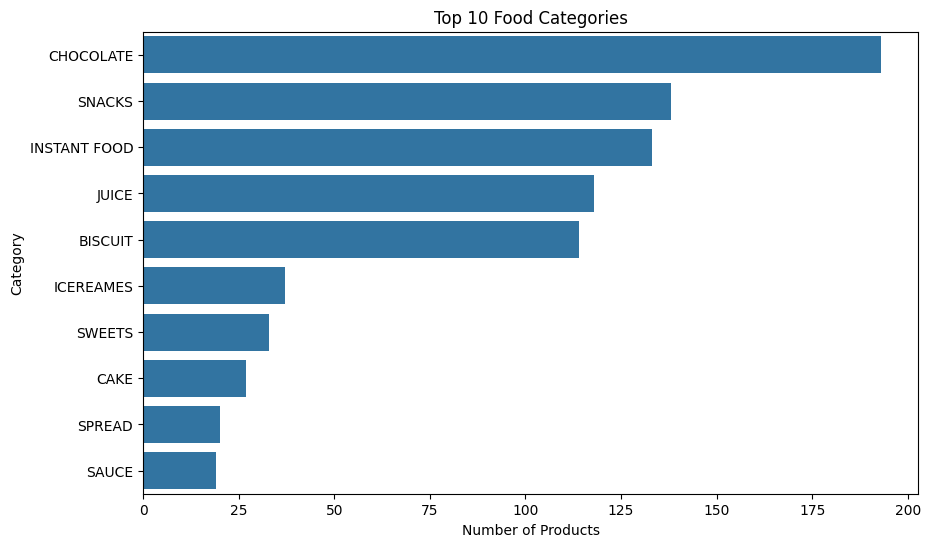

In [39]:
#10 most common food categories
plt.figure(figsize=(10, 6))
sns.countplot(
    y='Category',
    data=df,
    order=df['Category'].value_counts().head(10).index
)
plt.title('Top 10 Food Categories')
plt.xlabel('Number of Products')
plt.ylabel('Category')
plt.show()

In [40]:
#The top 10 brands
df['Brand_Name'].value_counts().head(10)


,count
Brand_Name,
BRITANNIA,34
PARLE,26
SUNFEAST,24
AMUL,24
CADBURY,22
PRASUMA,18
HALDIRAMS,16
HERSHEYS,15
DABUR REAL,14


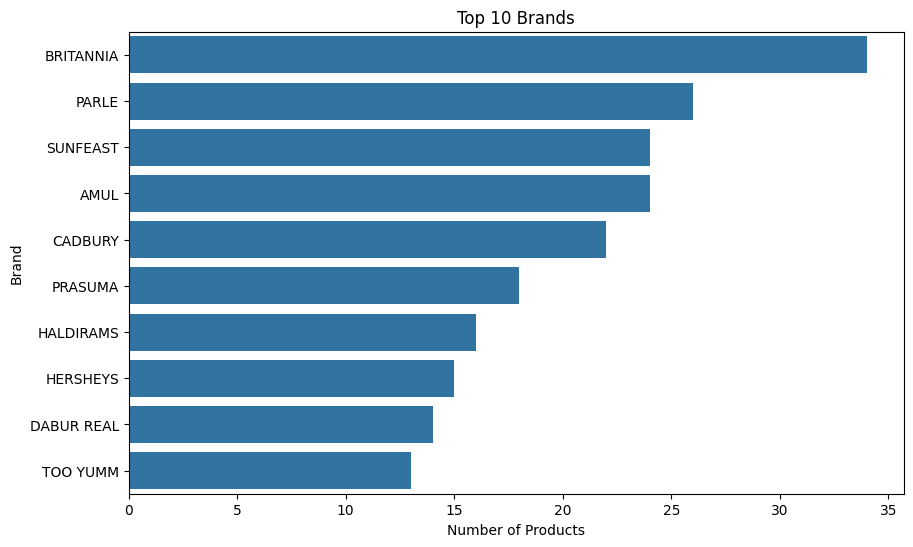

In [41]:
plt.figure(figsize=(10, 6))
sns.countplot(
    y='Brand_Name',
    data=df,
    order=df['Brand_Name'].value_counts().head(10).index
)
plt.title('Top 10 Brands')
plt.xlabel('Number of Products')
plt.ylabel('Brand')
plt.show()


In [42]:
#Average Calories by Category
category_calories = df.groupby('Category')['Calories_kcal'].mean().sort_values(ascending=False)
print(category_calories.head(10))

Category
SNACKS          474.507971
BISCUIT         459.202193
WAFFLE          453.756667
WAFER           444.066667
CHOCOLATE       423.075389
SWEETS          422.555455
CAKE            383.477778
SPREAD          311.845500
INSTANT FOOD    300.403910
DAIRY           226.154545
Name: Calories_kcal, dtype: float64


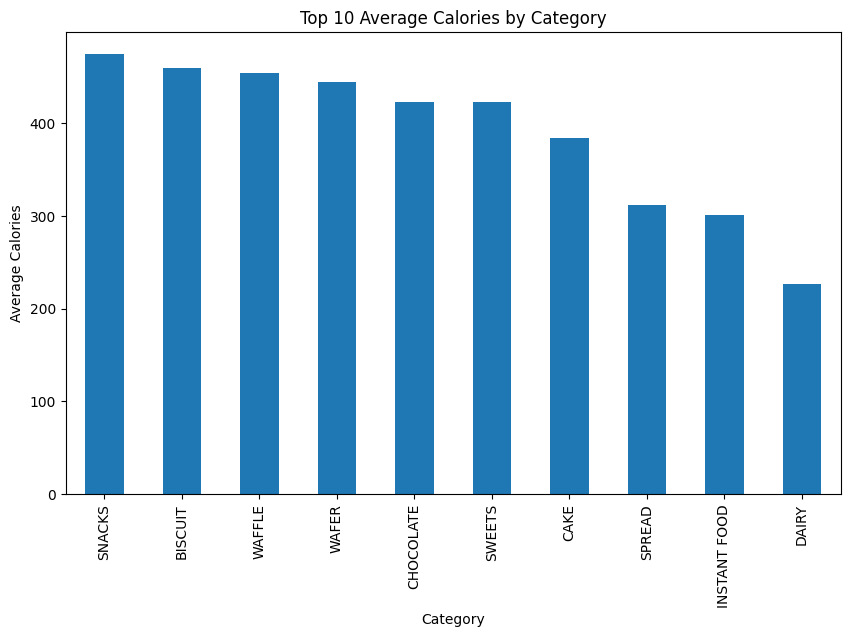

In [44]:
plt.figure(figsize=(10, 6))
category_calories.head(10).plot(kind='bar')
plt.title('Top 10 Average Calories by Category')
plt.xlabel('Category')
plt.ylabel('Average Calories')
plt.xticks(rotation=90)
plt.show()


Category
CHOCOLATE    47.702979
WAFER        40.733333
SWEETS       37.241212
WAFFLE       27.816667
CAKE         27.480370
SPREAD       23.742000
BISCUIT      23.013947
ICEREAMES    14.641216
JUICE        11.707754
SAUCE        10.683158
Name: Sugar_g, dtype: float64


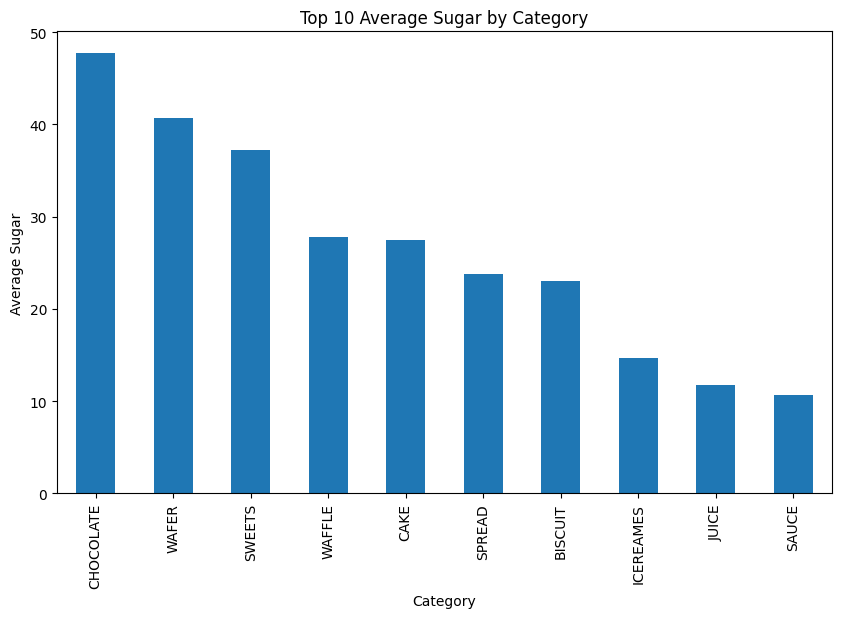

In [45]:
#Average Sugar by Category
category_sugar = df.groupby('Category')['Sugar_g'].mean().sort_values(ascending=False)
print(category_sugar.head(10))

plt.figure(figsize=(10, 6))
category_sugar.head(10).plot(kind='bar')
plt.title('Top 10 Average Sugar by Category')
plt.xlabel('Category')
plt.ylabel('Average Sugar')
plt.xticks(rotation=90)
plt.show()

Category
SNACKS       27.169058
WAFFLE       20.716667
BISCUIT      20.153947
SWEETS       19.439394
WAFER        18.066667
CAKE         18.000741
DAIRY        17.590909
CHOCOLATE    16.565026
SPREAD       15.735500
ICEREAMES    10.196216
Name: Total_Fat_g, dtype: float64


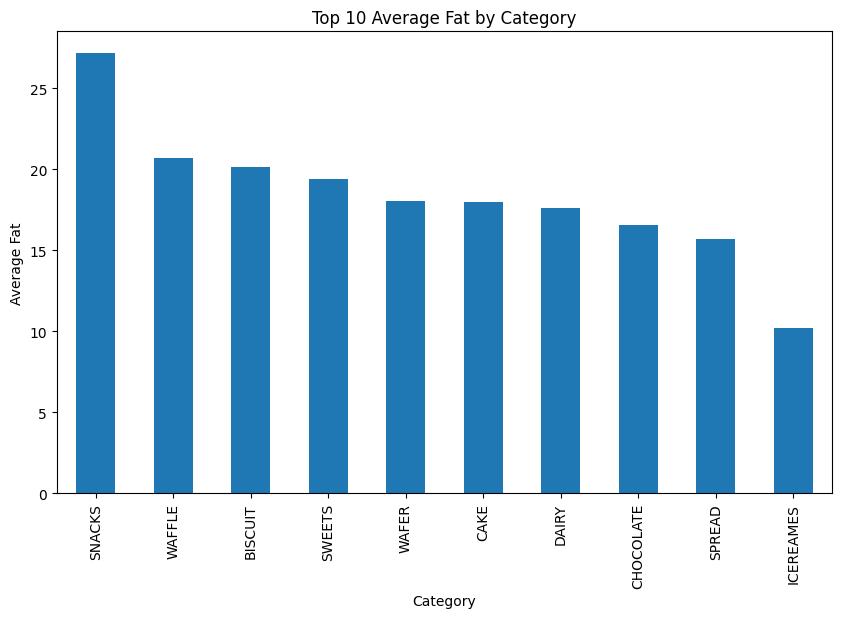

In [46]:
#Average Fat by Category
category_fat = df.groupby('Category')['Total_Fat_g'].mean().sort_values(ascending=False)
print(category_fat.head(10))

plt.figure(figsize=(10, 6))
category_fat.head(10).plot(kind='bar')
plt.title('Top 10 Average Fat by Category')
plt.xlabel('Category')
plt.ylabel('Average Fat')
plt.xticks(rotation=90)
plt.show()

Category
SNACKS          8.589855
BISCUIT         8.080789
INSTANT FOOD    8.026992
DAIRY           7.463636
SWEETS          7.154242
WAFFLE          6.916667
CAKE            5.883704
WAFER           5.400000
SPREAD          3.898000
CHOCOLATE       3.814922
Name: Proteins_g, dtype: float64


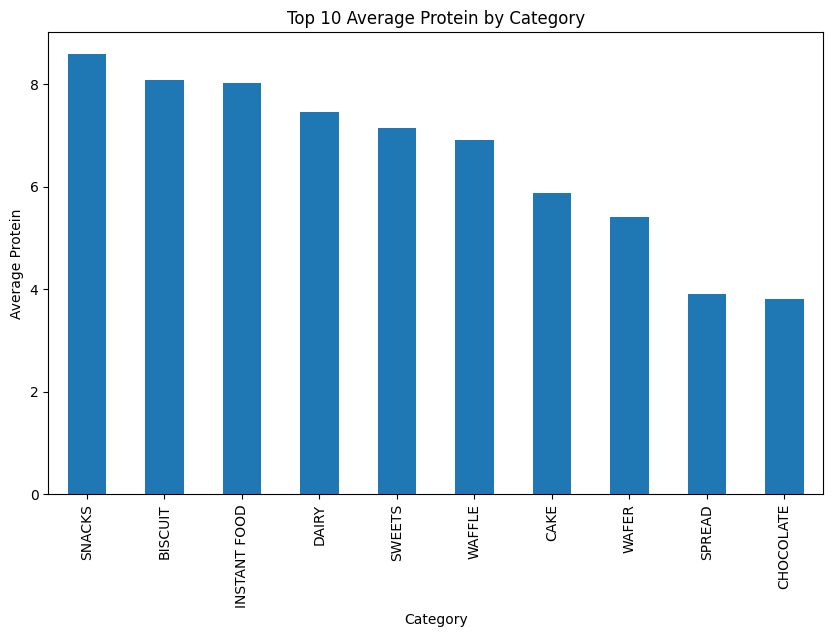

In [47]:
#Average Protein by Category
category_protein = df.groupby('Category')['Proteins_g'].mean().sort_values(ascending=False)
print(category_protein.head(10))

plt.figure(figsize=(10, 6))
category_protein.head(10).plot(kind='bar')
plt.title('Top 10 Average Protein by Category')
plt.xlabel('Category')
plt.ylabel('Average Protein')
plt.xticks(rotation=90)
plt.show()


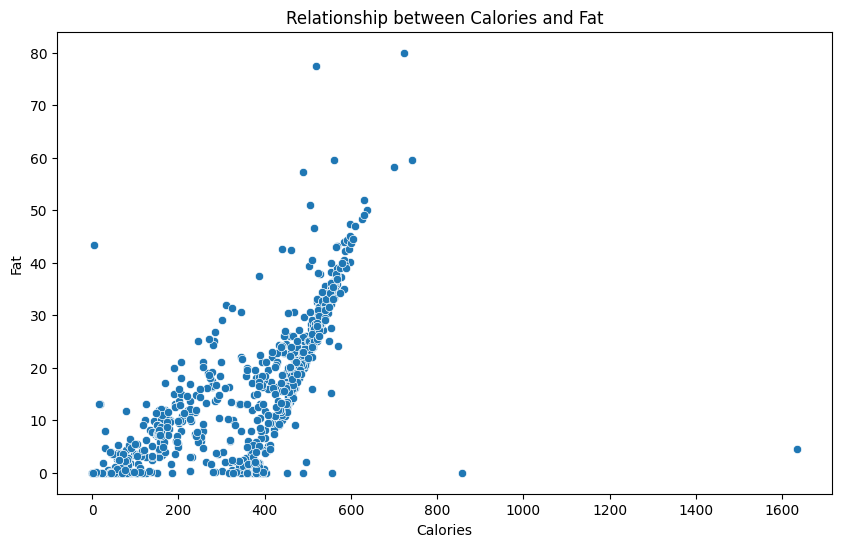

In [48]:
#Relationship Analysis of Fat vs Calories
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Calories_kcal',
    y='Total_Fat_g',
    data=df
)
plt.title('Relationship between Calories and Fat')
plt.xlabel('Calories')
plt.ylabel('Fat')
plt.show()

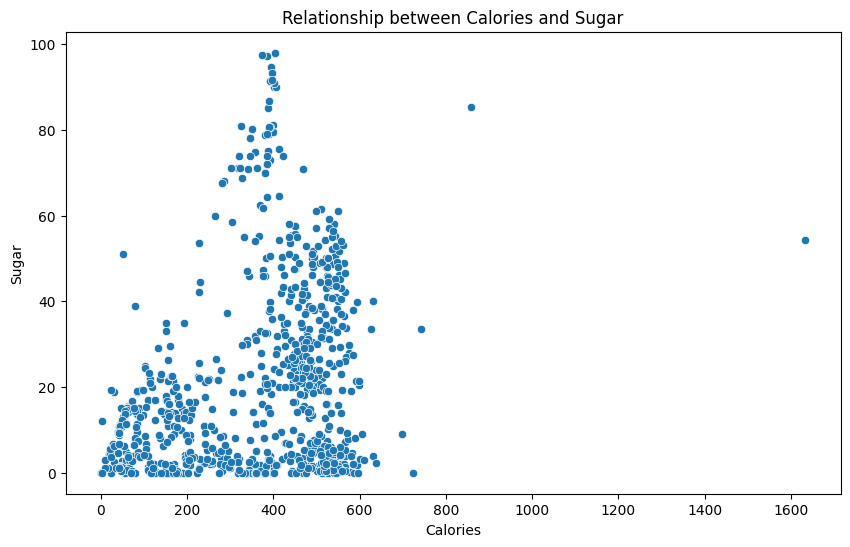

In [49]:
#Sugar vs Energy
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='Calories_kcal',
    y='Sugar_g',
    data=df
)
plt.title('Relationship between Calories and Sugar')
plt.xlabel('Calories')
plt.ylabel('Sugar')
plt.show()

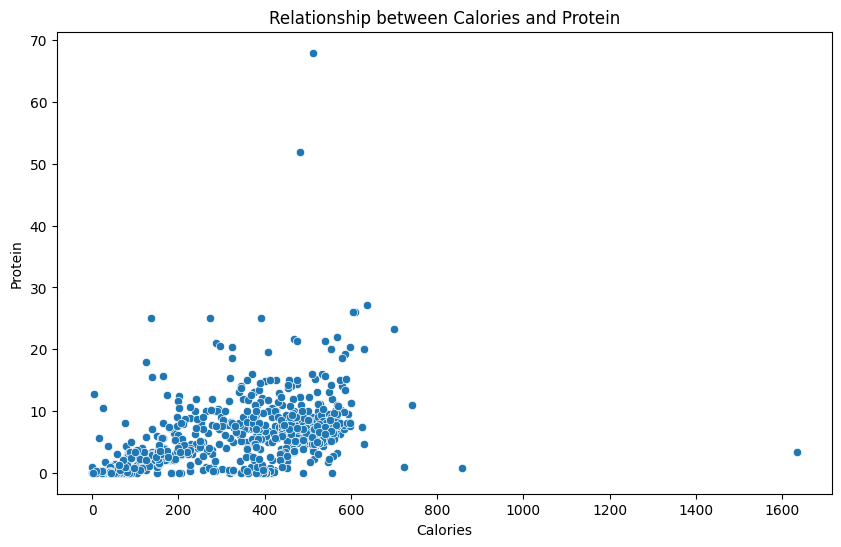

In [50]:
#Protein vs Calories
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='Calories_kcal',
    y='Proteins_g',
    data=df
)
plt.title('Relationship between Calories and Protein')
plt.xlabel('Calories')
plt.ylabel('Protein')
plt.show()


In [52]:
#Top 10 categories by number of products
print("TOP 10 CATEGORIES")
print(df['Category'].value_counts().head(10))

#Top 10 Brands
print("\nTOP 10 BRANDS")
print(df['Brand_Name'].value_counts().head(10))

#Average nutrition by category
print("\nAVERAGE NUTRITION BY CATEGORY")
nutrition_by_category = df.groupby('Category')[
    ['Calories_kcal', 'Proteins_g', 'Total_Fat_g', 'Carbohydrates_g', 'Sugar_g']
].mean().sort_values(by='Calories_kcal', ascending=False)
print(nutrition_by_category.head(10))

#Strongest correlations
print("\nCORRELATION MATRIX")
correlation_matrix = df[numeric_cols].corr().round(2)
print(correlation_matrix)



TOP 10 CATEGORIES
Category
CHOCOLATE       193
SNACKS          138
INSTANT FOOD    133
JUICE           118
BISCUIT         114
ICEREAMES        37
SWEETS           33
CAKE             27
SPREAD           20
SAUCE            19
Name: count, dtype: int64

TOP 10 BRANDS
Brand_Name
BRITANNIA     34
PARLE         26
SUNFEAST      24
AMUL          24
CADBURY       22
PRASUMA       18
HALDIRAMS     16
HERSHEYS      15
DABUR REAL    14
TOO YUMM      13
Name: count, dtype: int64

AVERAGE NUTRITION BY CATEGORY
              Calories_kcal  Proteins_g  Total_Fat_g  Carbohydrates_g  \
Category                                                                
SNACKS           474.507971    8.589855    27.169058        51.833116   
BISCUIT          459.202193    8.080789    20.153947        67.754211   
WAFFLE           453.756667    6.916667    20.716667        60.561667   
WAFER            444.066667    5.400000    18.066667        66.866667   
CHOCOLATE        423.075389    3.814922    16.565026    

In [53]:
df.shape

(852, 21)

In [54]:
df.isnull().sum()

,0
S.No,0
Item name,0
Brand_Name,0
Category,0
Sub_Category,0
Ingredients,0
Serving_Size_g,0
Calories_kcal,0
Carbohydrates_g,0
Proteins_g,0


In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
df.dtypes

,0
S.No,int64
Item name,object
Brand_Name,object
Category,object
Sub_Category,object
Ingredients,object
Serving_Size_g,float64
Calories_kcal,float64
Carbohydrates_g,float64
Proteins_g,float64


In [58]:
df.to_csv('packaged_foods_cleaned.csv', index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [59]:
from google.colab import files
files.download('packaged_foods_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
print(f"Maximum Price of a product: {df['Price_INR'].max()} INR")

Maximum Price of a product: 1199.0 INR
